In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','notebook','light'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']

### Lorenz 96, embeddings

In [2]:
Es = np.arange(1,41)
alphas = np.linspace(0.,1.5,50)

info_imbalances_X_to_Y_null = np.zeros((1000,len(Es),len(alphas)))
info_imbalances_Y_to_X_null = np.zeros((1000,len(Es),len(alphas)))

for seed in range(1000):
    info_imbalances_X_to_Y_null[seed], info_imbalances_Y_to_X_null[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}.p","rb"))
print(info_imbalances_X_to_Y_null.shape, info_imbalances_Y_to_X_null.shape)

IGs_X_to_Y_null = 100*(info_imbalances_X_to_Y_null[:,:,0,np.newaxis]-np.min(info_imbalances_X_to_Y_null,axis=-1,keepdims=True)) \
    / info_imbalances_X_to_Y_null[:,:,0,np.newaxis]
IGs_Y_to_X_null = 100*(info_imbalances_Y_to_X_null[:,:,0,np.newaxis]-np.min(info_imbalances_Y_to_X_null,axis=-1,keepdims=True)) \
    / info_imbalances_Y_to_X_null[:,:,0,np.newaxis]
print(IGs_X_to_Y_null.shape, IGs_Y_to_X_null.shape)


(1000, 40, 50) (1000, 40, 50)
(1000, 40, 1) (1000, 40, 1)


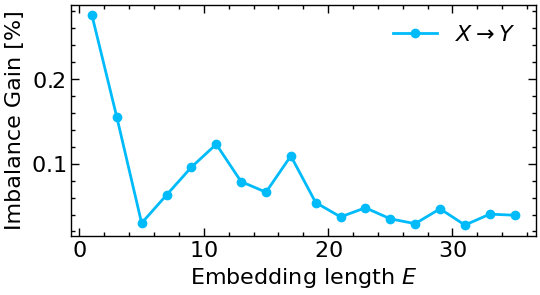

Es = [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35]


In [52]:
indices = np.arange(0,35,2)

plt.figure(figsize=(6,3))
#plt.errorbar(Es, IGs_X_to_Y_null.mean(axis=0).flatten(), IGs_X_to_Y_null.std(axis=0).flatten(), label="$X\\rightarrow Y$")# / np.sqrt(1000),
#plt.errorbar(Es, IGs_Y_to_X_null.mean(axis=0).flatten(), IGs_Y_to_X_null.std(axis=0).flatten(), label="$Y\\rightarrow X$")# / np.sqrt(1000),
plt.plot(Es[indices], IGs_X_to_Y_null.mean(axis=0)[indices], markers[0], label="$X\\rightarrow Y$", color=colors[0], zorder=3)
plt.plot(Es[indices], IGs_Y_to_X_null.mean(axis=0)[indices], markers[1], label="$Y\\rightarrow X$", color=colors[1])
plt.xlabel("Embedding length $E$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.show()

print(f"Es = {Es[indices]}")

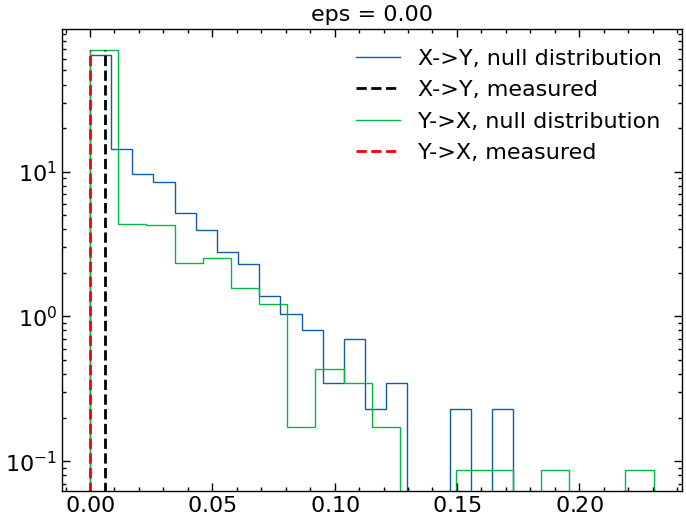

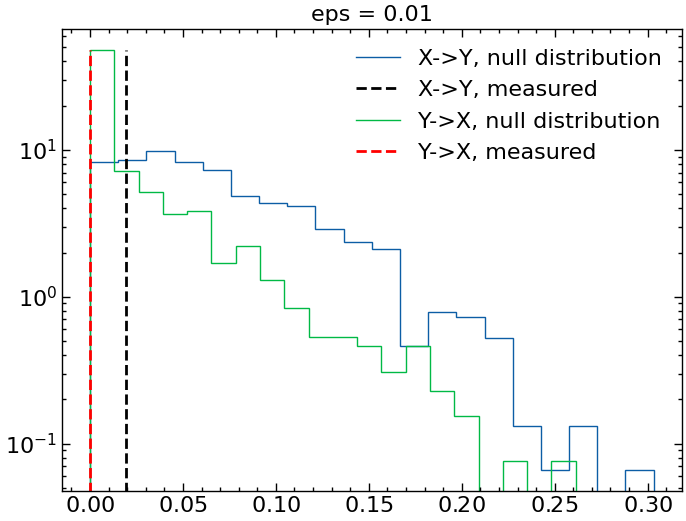

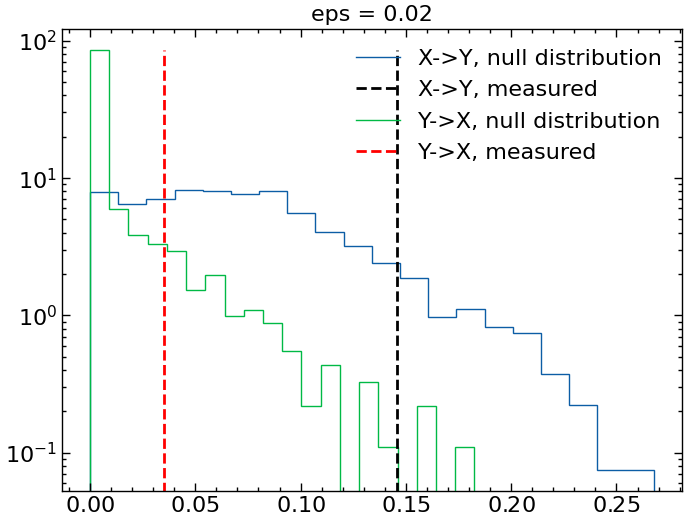

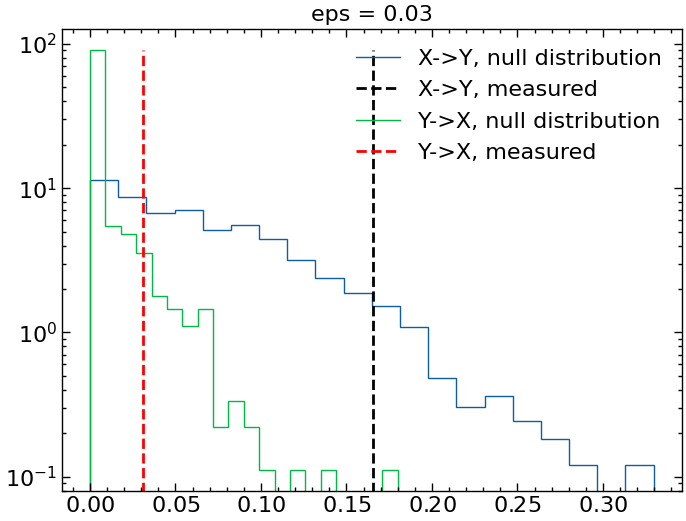

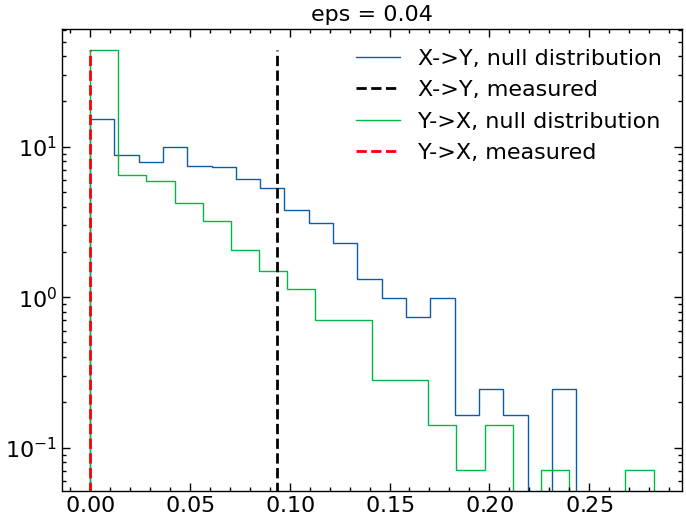

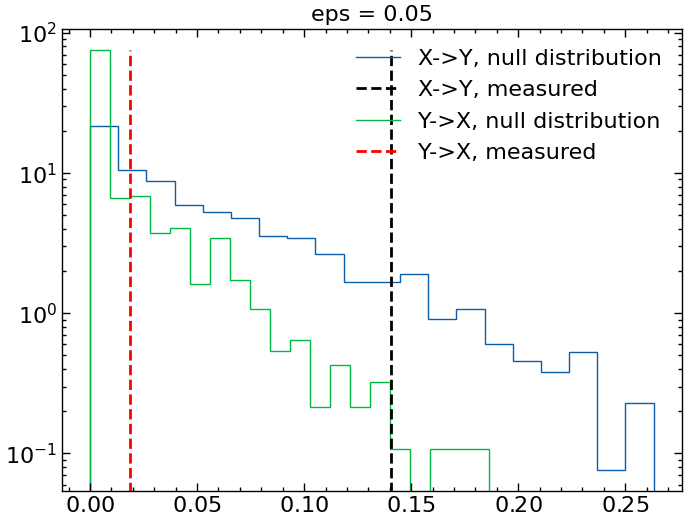

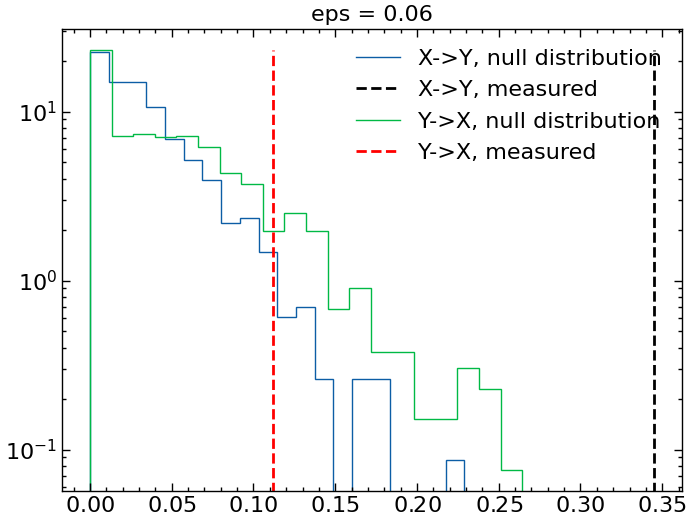

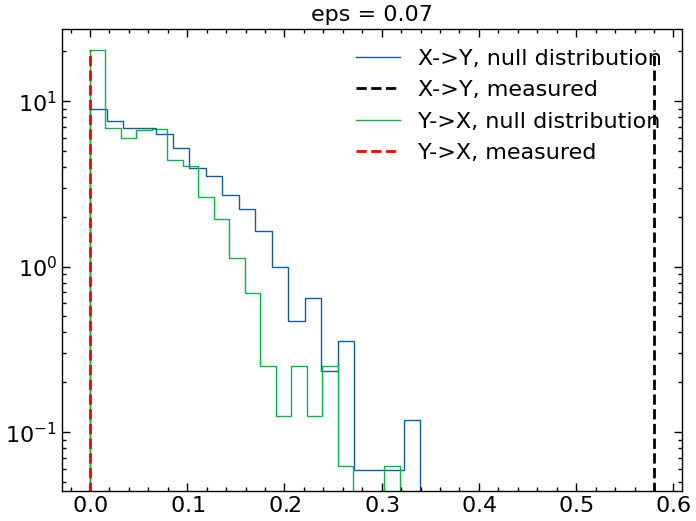

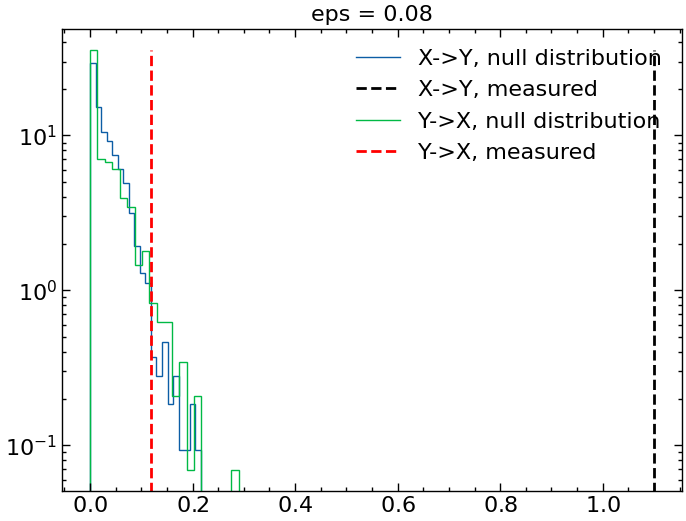

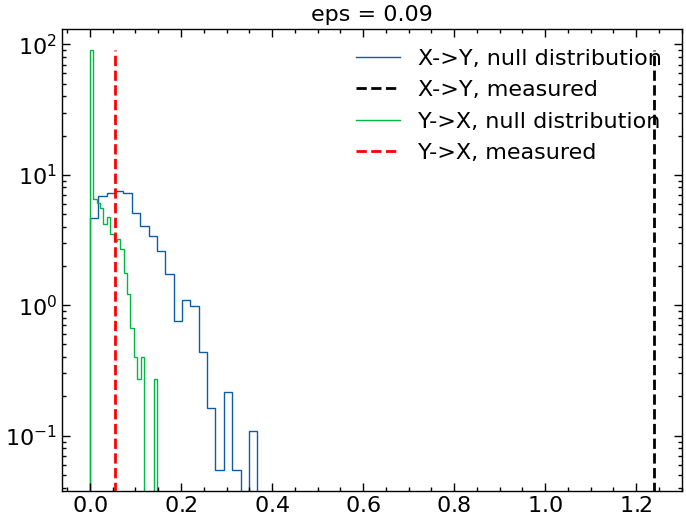

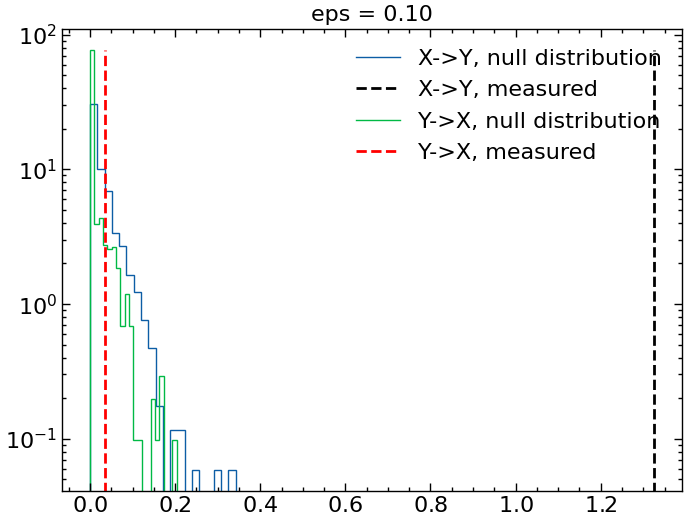

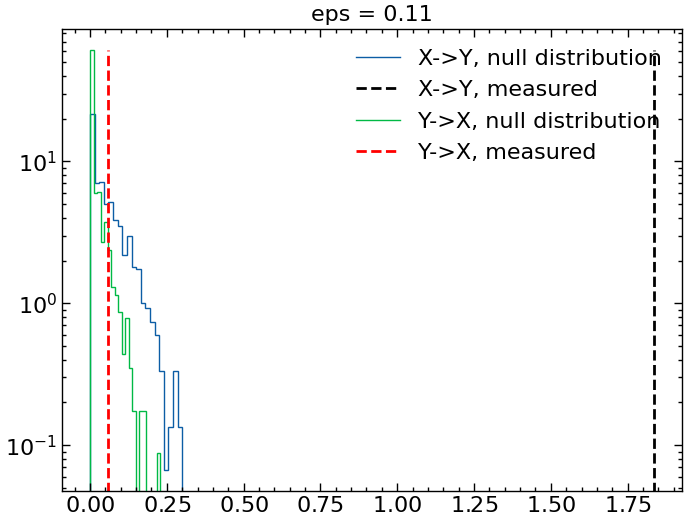

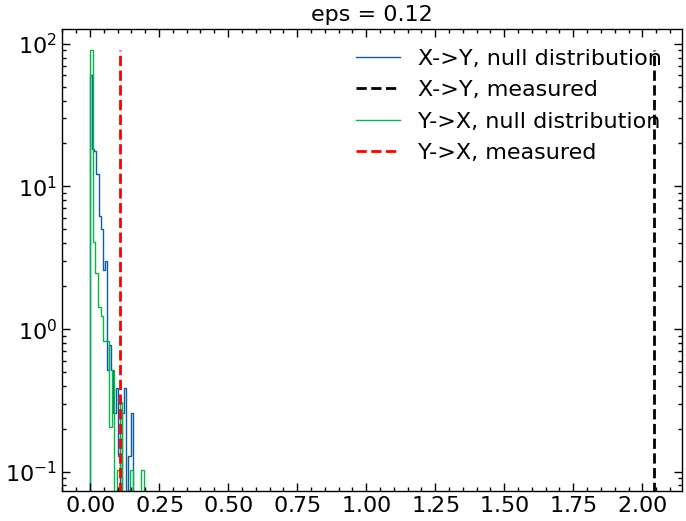

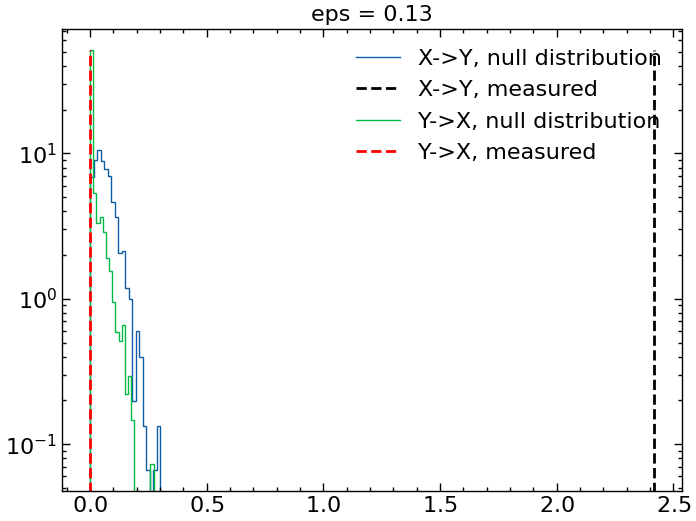

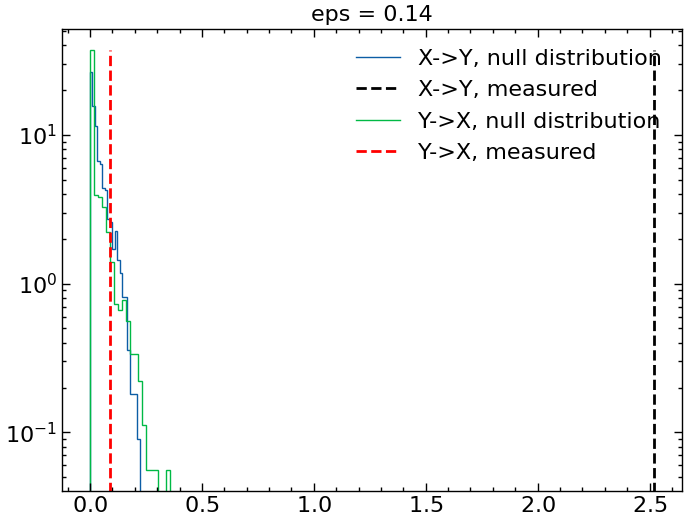

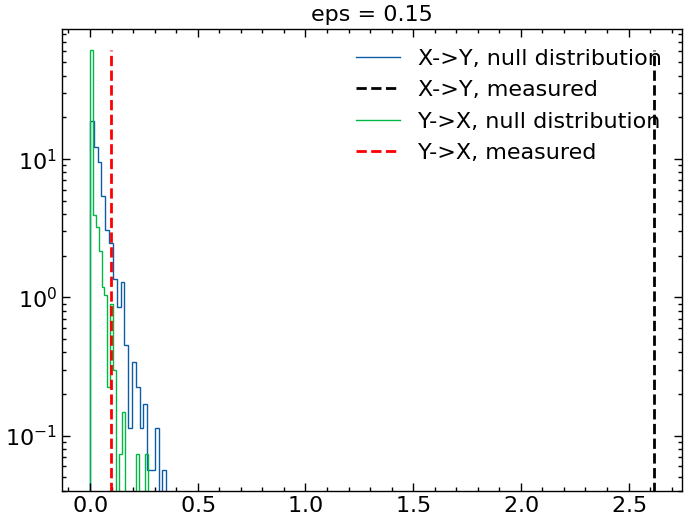

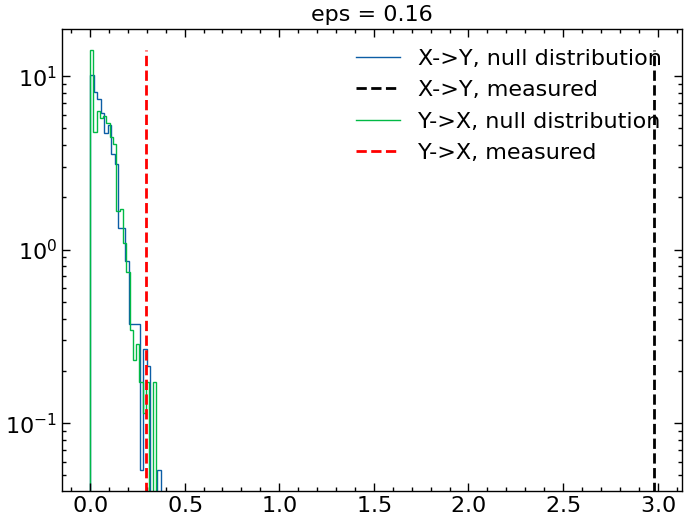

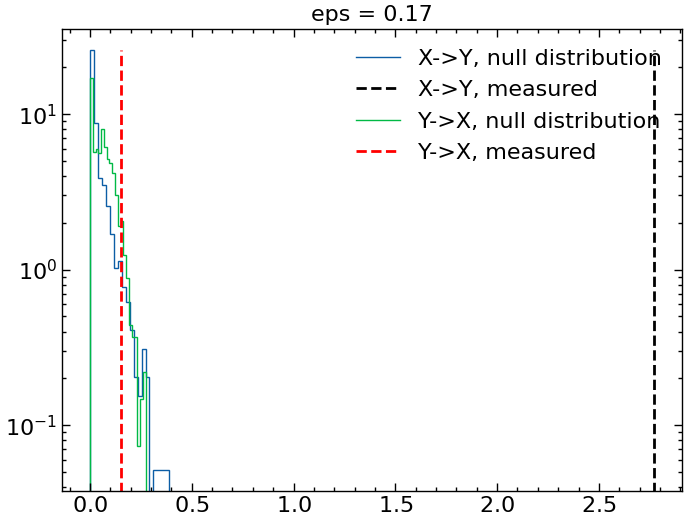

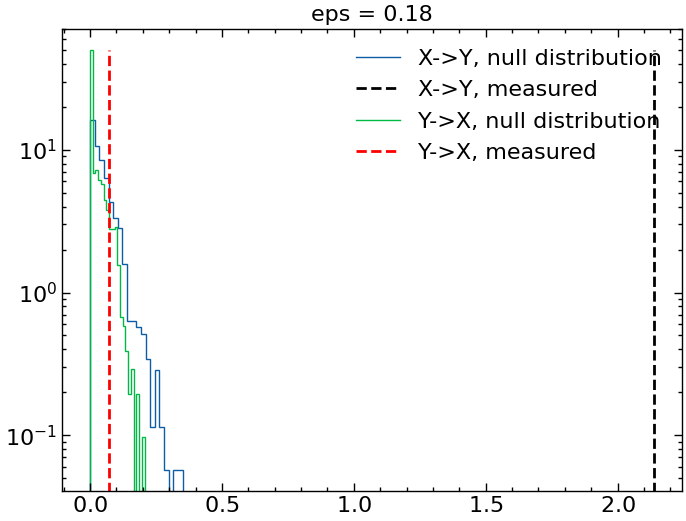

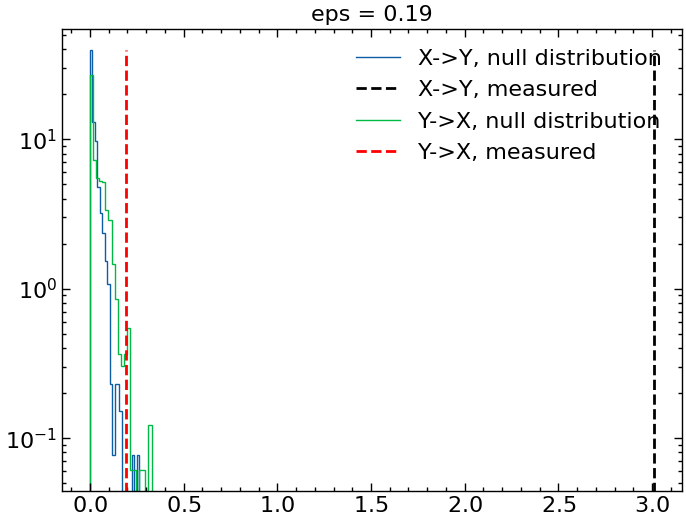

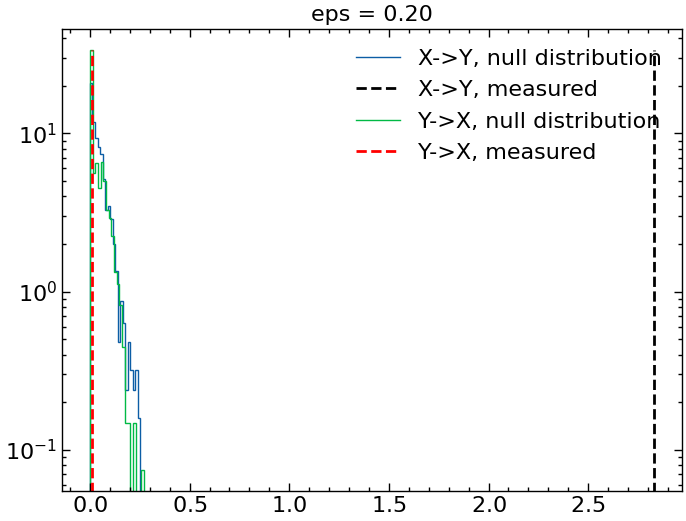

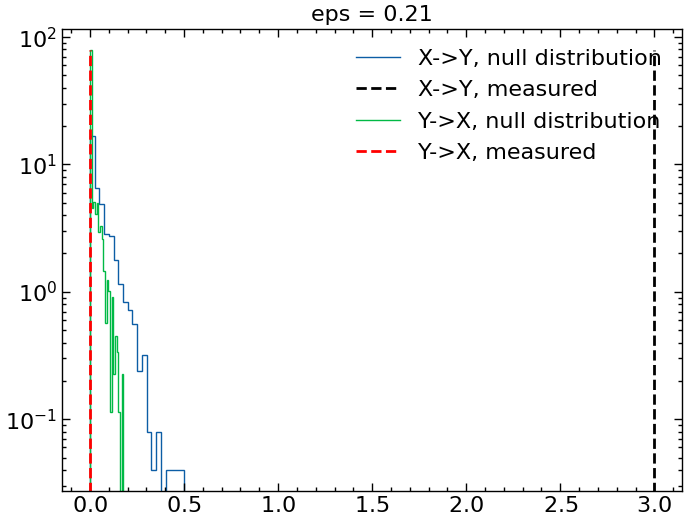

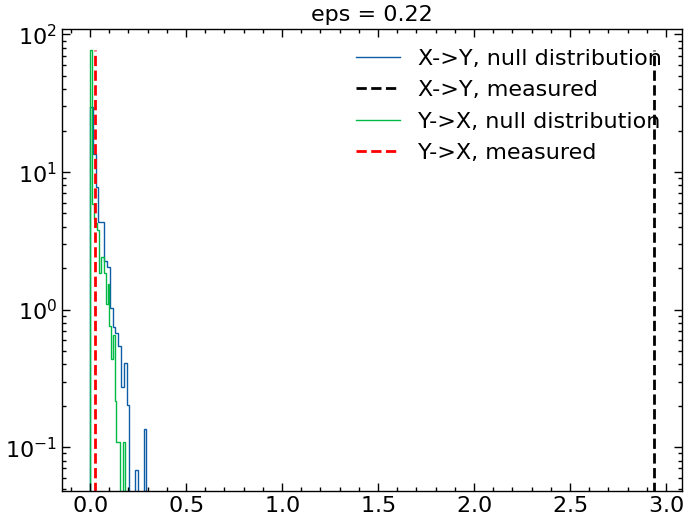

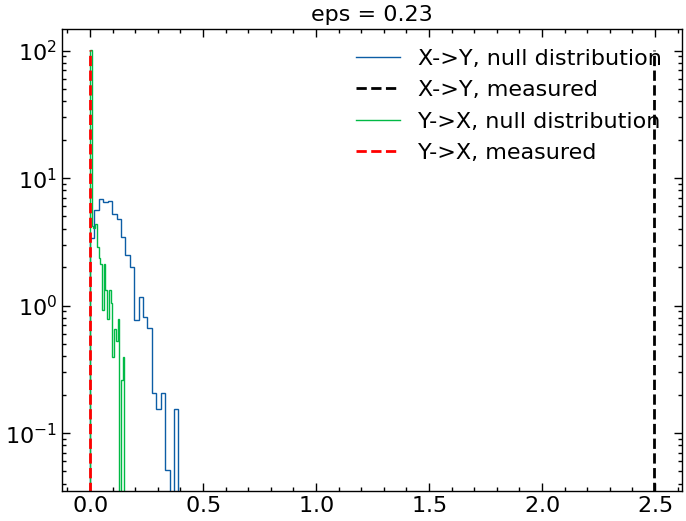

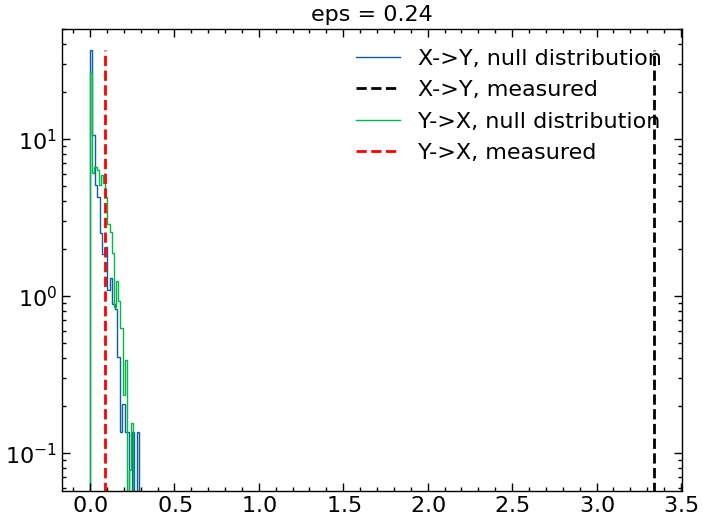

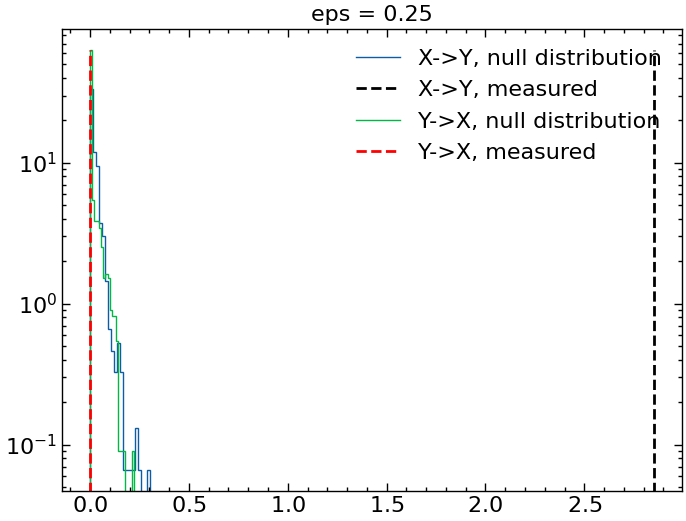

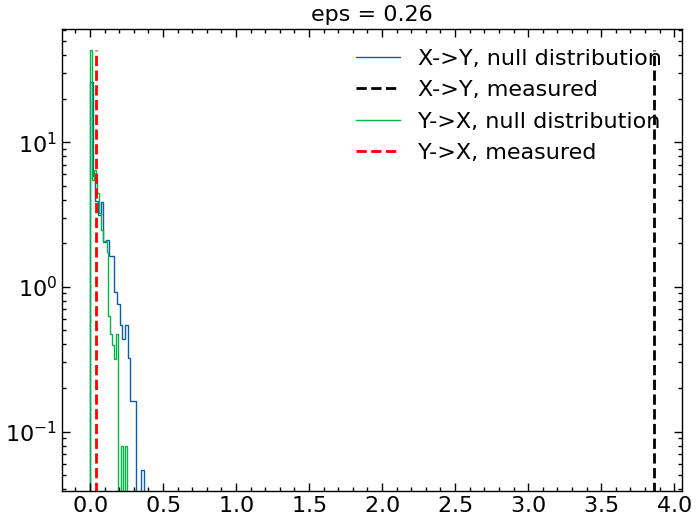

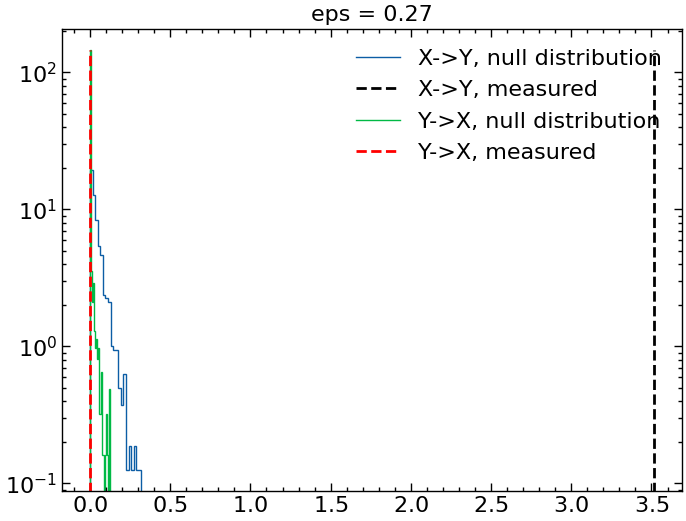

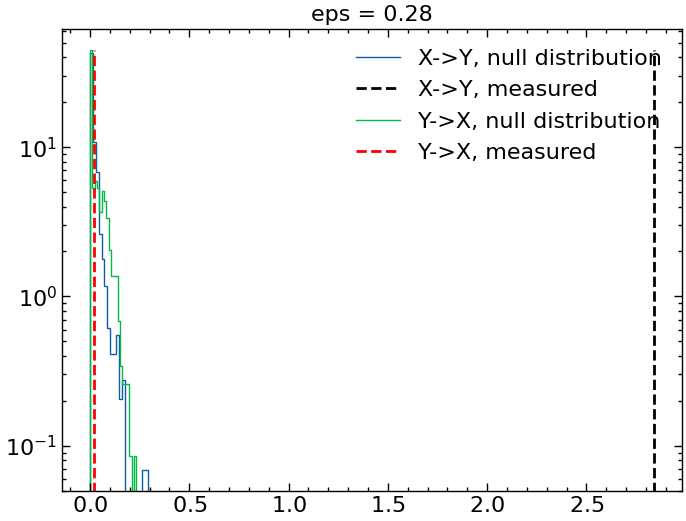

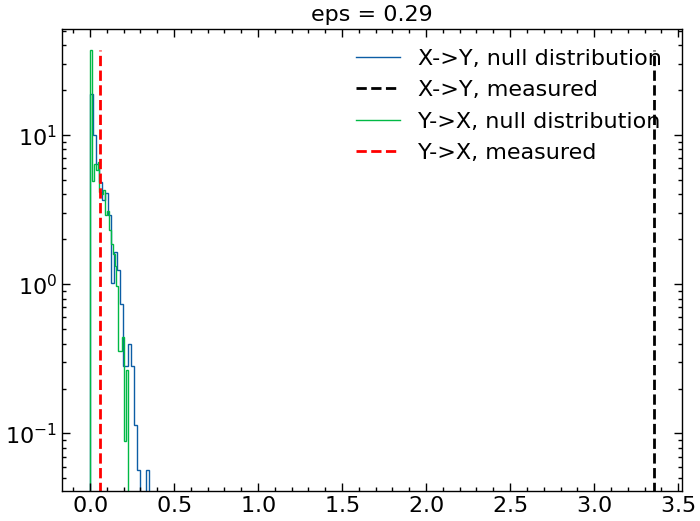

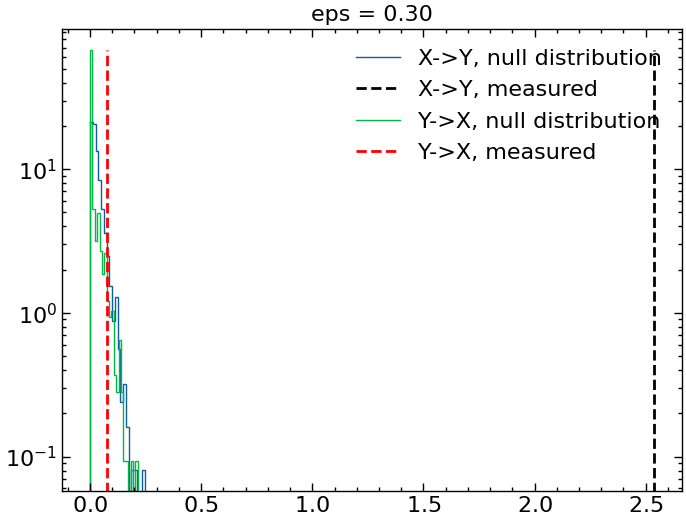

True positive detections: 25/31 (80.65%)
False positive detections: 2/31 (6.45%)


In [10]:
n_tpd = 0 # number of true positive detections
n_fpd = 0 # number of false positive detections

for iE, E in enumerate(Es):
    counts_XtoY, bins_XtoY = np.histogram(IGs_X_to_Y_null[:,iE], bins=20, density=True)
    counts_YtoX, bins_YtoX = np.histogram(IGs_Y_to_X_null[:,iE], bins=20, density=True)
    
    plt.stairs(counts_XtoY, bins_XtoY, label="X->Y, null distribution")
    #plt.hist(IGs_X_to_Y_null[:,ieps], bins=100, alpha=0.5)
    plt.title(f"eps = {eps:.2f}")

    plt.stairs(counts_YtoX, bins_YtoX, label="Y->X, null distribution")
    #plt.hist(IGs_Y_to_X_null[:,ieps], bins=100, alpha=0.5)
    plt.title(f"eps = {eps:.2f}")

    plt.yscale("log")
    plt.legend()
    plt.show()